In [1]:
import dgl
import torch
import CAST
import os
import numpy as np
import anndata as ad
import scanpy as sc
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from CAST import CAST_MARK
from CAST.visualize import kmeans_plot_multiple
from CAST import CAST_STACK
from CAST.CAST_Stack import reg_params
from CAST.models.model_GCNII import Args
from scipy.sparse import issparse
from scipy.spatial import cKDTree
from sklearn.neighbors import NearestNeighbors



In [15]:
warnings.filterwarnings("ignore")
work_dir = '/p1/data/jtian/SA/embyro'
output_path = f'{work_dir}/output'
os.makedirs(output_path, exist_ok=True)

In [ ]:
#create trans adata

In [ ]:



# 你的数据根目录（按需改）
input_root = "/p1/data/jtian/SA/embyro/input"   # 里面有 e1/ e2/ 子文件夹
SAMPLE_IDS = ["e1", "e2"]

print("开始分别构建每个样本的 AnnData...")

adata_dict = {}  # 用来存 e1/e2 两个 AnnData

for sample_id in SAMPLE_IDS:
    sample_dir = os.path.join(input_root, sample_id)
    print(f"\n处理样本 {sample_id}...")

    # --- 1. 读表达矩阵 (mtx) ---
    mtx_gz = os.path.join(sample_dir, "matrix.mtx.gz")
    X = sc.read_mtx(mtx_gz).X

    # mtx 通常是 (genes x cells)，转成 (cells x genes)
    X_t = X.T.tocsr()

    # --- 2. 读 barcodes / genes ---
    barcodes_path = os.path.join(sample_dir, "barcodes.txt")
    genes_path = os.path.join(sample_dir, "genes.txt")

    barcodes = pd.read_csv(
        barcodes_path, header=None, sep=r"\s+", usecols=[0], engine="python"
    )[0].astype(str).values

    genes = pd.read_csv(
        genes_path, header=None, sep=r"\s+", usecols=[0], engine="python"
    )[0].astype(str).values

    # --- 3. 读坐标并对齐到 barcodes ---
    coord_path = os.path.join(sample_dir, f"{sample_id}_transcriptomics_cell_coordinates.csv")
    coord = pd.read_csv(coord_path)

    coord["cell"] = coord["cell"].astype(str)
    coord = coord.set_index("cell").reindex(barcodes)

    missing = coord[["x", "y"]].isna().any(axis=1).sum()
    if missing > 0:
        print(f"⚠️ 警告：样本 {sample_id} 有 {missing} 个 barcode 在坐标文件中找不到对应 (x,y)，将为 NaN。")

    # --- 4. 构建 obs / var ---
    obs_t = pd.DataFrame(index=barcodes)
    obs_t["x"] = np.floor(coord["x"].astype(float).values).astype(int)
    obs_t["y"] = np.floor(coord["y"].astype(float).values).astype(int)
    obs_t["sample"] = str(sample_id)

    var_df = pd.DataFrame(index=pd.Index(genes.astype(str)))

    # --- 5. 构建 AnnData（单样本） ---
    adata = ad.AnnData(X=X_t, obs=obs_t, var=var_df)

    # 常用：把空间坐标也放到 obsm['spatial']
    adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()

    # 去重
    adata.var_names_make_unique()
    adata.obs_names_make_unique()

    # 存到字典里
    adata_dict[sample_id] = adata

    print(adata)

    
# 保存成 h5ad
adataTrans1 = adata_dict["e1"].copy()
adataTrans2 = adata_dict["e2"].copy()
adataTrans1.obs['sample'] = 'trans1'
adataTrans2.obs['sample'] = 'trans2'
adataTrans1.write_h5ad('/p1/data/jtian/SA/embyro/output/adataTrans1.h5ad')
adataTrans2.write_h5ad('/p1/data/jtian/SA/embyro/output/adataTrans2.h5ad')

开始分别构建每个样本的 AnnData...

处理样本 e1...
AnnData object with n_obs × n_vars = 256626 × 44374
    obs: 'x', 'y', 'sample'
    obsm: 'spatial'

处理样本 e2...
AnnData object with n_obs × n_vars = 291179 × 45582
    obs: 'x', 'y', 'sample'
    obsm: 'spatial'


In [ ]:
#处理adataTrans1

In [7]:
adataTrans1 = sc.read_h5ad('/p1/data/jtian/SA/embyro/output/adataTrans1.h5ad')

In [8]:
adataTrans1

AnnData object with n_obs × n_vars = 256626 × 44374
    obs: 'x', 'y', 'sample'
    obsm: 'spatial'

In [9]:
sc.pp.calculate_qc_metrics(adataTrans1,inplace=True)

/p1/zulab_users/jtian/anaconda3/envs/my_NewSA_py39/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [10]:
adataTrans1

AnnData object with n_obs × n_vars = 256626 × 44374
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

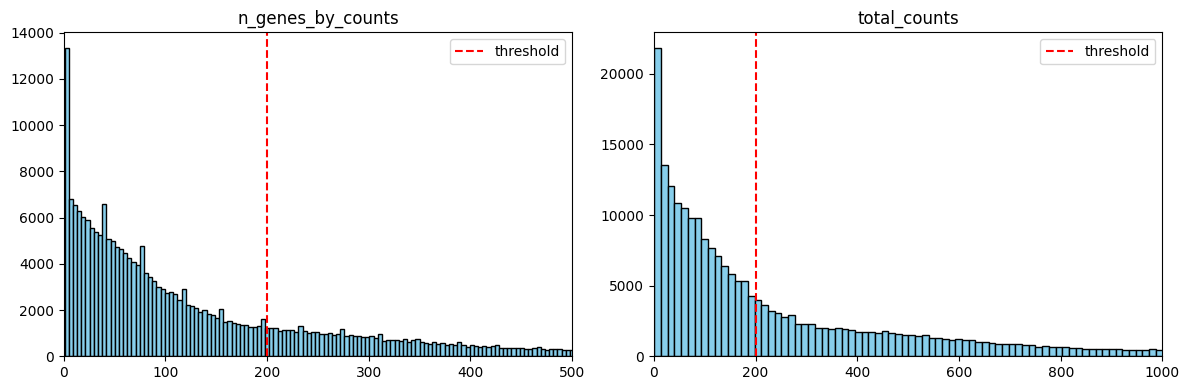

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# n_genes_by_counts
axs[0].hist(
    adataTrans1.obs['n_genes_by_counts'],
    bins=1000,
    color='skyblue',
    edgecolor='black'
)
axs[0].set_title('n_genes_by_counts')
axs[0].set_xlim(0, 500)      # 👈 这里：横坐标到 500

# total_counts
axs[1].hist(
    adataTrans1.obs['total_counts'],
    bins=1000,
    color='skyblue',
    edgecolor='black'
)
axs[1].set_title('total_counts')
axs[1].set_xlim(0, 1000)     # 👈 这里：横坐标到 1000
axs[0].axvline(200, color='red', linestyle='--', label='threshold')
axs[0].legend()

axs[1].axvline(200, color='red', linestyle='--', label='threshold')
axs[1].legend()

plt.tight_layout()
plt.show()



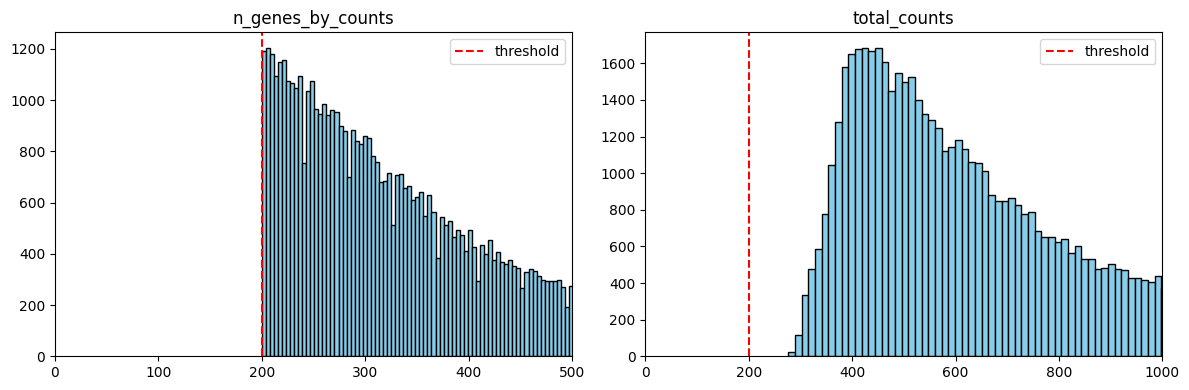

In [19]:
sc.pp.filter_cells(adataTrans1, min_genes=200)  # this does nothing, in this specific case
sc.pp.filter_genes(adataTrans1, min_cells=100)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# n_genes_by_counts
axs[0].hist(
    adataTrans1.obs['n_genes_by_counts'],
    bins=1000,
    color='skyblue',
    edgecolor='black'
)
axs[0].set_title('n_genes_by_counts')
axs[0].set_xlim(0, 500)      # 👈 这里：横坐标到 500

# total_counts
axs[1].hist(
    adataTrans1.obs['total_counts'],
    bins=1000,
    color='skyblue',
    edgecolor='black'
)
axs[1].set_title('total_counts')
axs[1].set_xlim(0, 1000)     # 👈 这里：横坐标到 1000
axs[0].axvline(200, color='red', linestyle='--', label='threshold')
axs[0].legend()

axs[1].axvline(200, color='red', linestyle='--', label='threshold')
axs[1].legend()

plt.tight_layout()
plt.show()




preprocess前:
0.0 1591.0
CPM后:
0.0 3073.991
log变换后:
0.0 8.031057


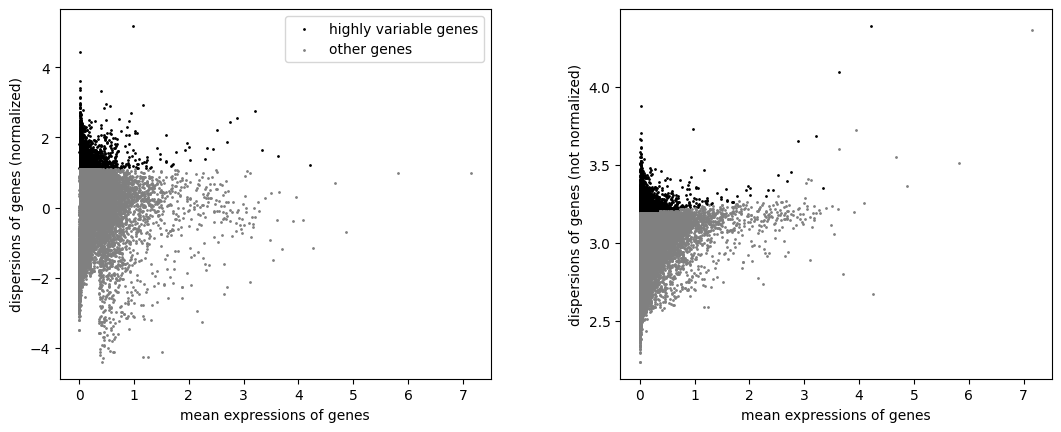

In [21]:
print("preprocess前:")
print(adataTrans1.X.min(), adataTrans1.X.max())
adataTrans1.layers['raw'] = adataTrans1.X.copy()

# CPM
sc.pp.normalize_total(adataTrans1, target_sum=1e4)
print('CPM后:')
print(adataTrans1.X.min(), adataTrans1.X.max())

# log 
sc.pp.log1p(adataTrans1)
print("log变换后:")
print(adataTrans1.X.min(), adataTrans1.X.max())

# # scale
# sc.pp.scale(adataTrans1, zero_center=False)

# find highly_variable_genes
sc.pp.highly_variable_genes(
    adataTrans1,
    n_top_genes=2000,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    flavor="seurat",
)
sc.pl.highly_variable_genes(adataTrans1)


In [23]:
adataTrans1

AnnData object with n_obs × n_vars = 86201 × 20406
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    obsm: 'spatial'
    layers: 'raw'

In [25]:
def plot_spatial_counts_from_X(adata, layer="raw", s=2, title=""):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.sparse import issparse

    if "spatial" in adata.obsm:
        xy = adata.obsm["spatial"]
    else:
        xy = adata.obs[["x","y"]].values

    X = adata.layers[layer] if layer is not None else adata.X
    if issparse(X):
        counts = np.asarray(X.sum(axis=1)).ravel()
    else:
        counts = X.sum(axis=1)

    plt.figure(figsize=(6,6))
    plt.scatter(
        xy[:,0], xy[:,1],
        c=np.log1p(counts),
        s=s, cmap="viridis"
    )
    plt.colorbar(label="log1p(total counts)")
    plt.gca().set_aspect("equal")
    plt.title(title)
    plt.tight_layout()
    plt.show()


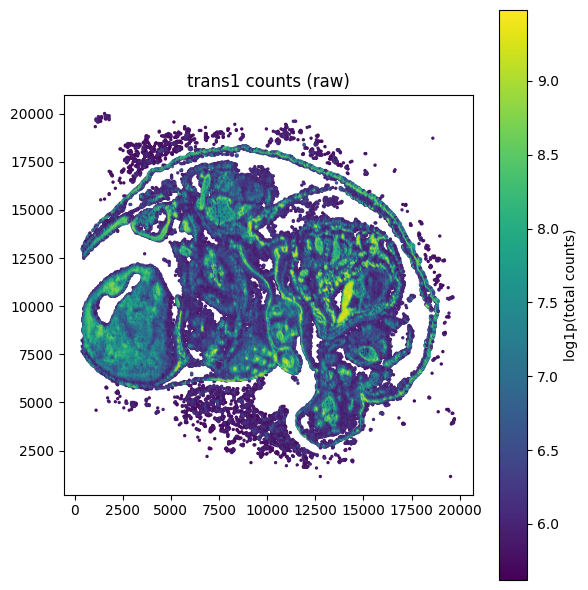

In [27]:
sc.pp.filter_cells(adataTrans1, min_genes=200)
plot_spatial_counts_from_X(
    adataTrans1,
    layer="raw",
    title="trans1 counts (raw)"
)

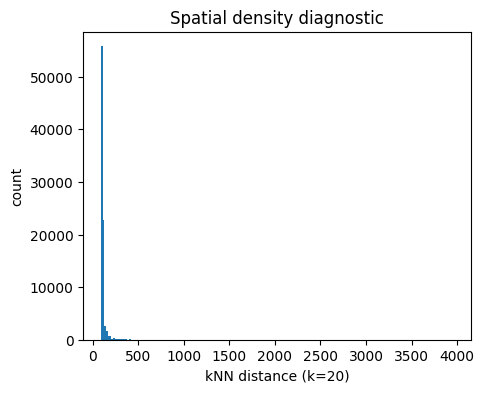

In [32]:
xy = adataTrans1.obsm["spatial"]

# kNN（推荐 k=15~30）
k = 20
nbrs = NearestNeighbors(n_neighbors=k).fit(xy)
dists, _ = nbrs.kneighbors(xy)

# 用第 k 个邻居距离作为“局部稀疏度”
knn_dist = dists[:, -1]   # 越大 = 越稀疏
adataTrans1.obs["knn_dist"] = knn_dist
plt.figure(figsize=(5,4))
plt.hist(knn_dist, bins=200)
plt.xlabel("kNN distance (k=20)")
plt.ylabel("count")
plt.title("Spatial density diagnostic")
plt.show()

保留点数: 81042 / 85790


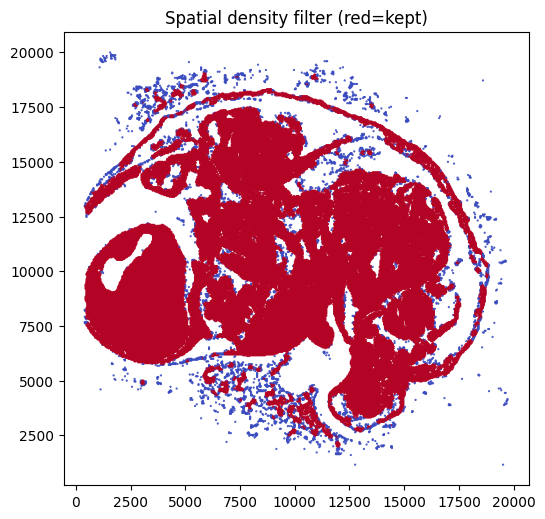

In [33]:
thr = np.percentile(knn_dist, 95)
keep = knn_dist < thr
print("保留点数:", keep.sum(), "/", len(keep))

adataTrans1 = adataTrans1[keep].copy()
plt.figure(figsize=(6,6))
plt.scatter(
    xy[:,0], xy[:,1],
    c=keep,
    s=0.3,
    cmap="coolwarm"
)
plt.title("Spatial density filter (red=kept)")
plt.gca().set_aspect("equal")
plt.show()



In [34]:
adataTrans1.write_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataTrans1.h5ad')

In [ ]:
#处理adataTrans2

In [12]:
adataTrans2 = sc.read_h5ad('/p1/data/jtian/SA/embyro/output/adataTrans2.h5ad')

In [14]:
adataTrans2

AnnData object with n_obs × n_vars = 291179 × 45582
    obs: 'x', 'y', 'sample'
    obsm: 'spatial'

In [15]:
sc.pp.calculate_qc_metrics(adataTrans2,inplace=True)

In [16]:
adataTrans2

AnnData object with n_obs × n_vars = 291179 × 45582
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

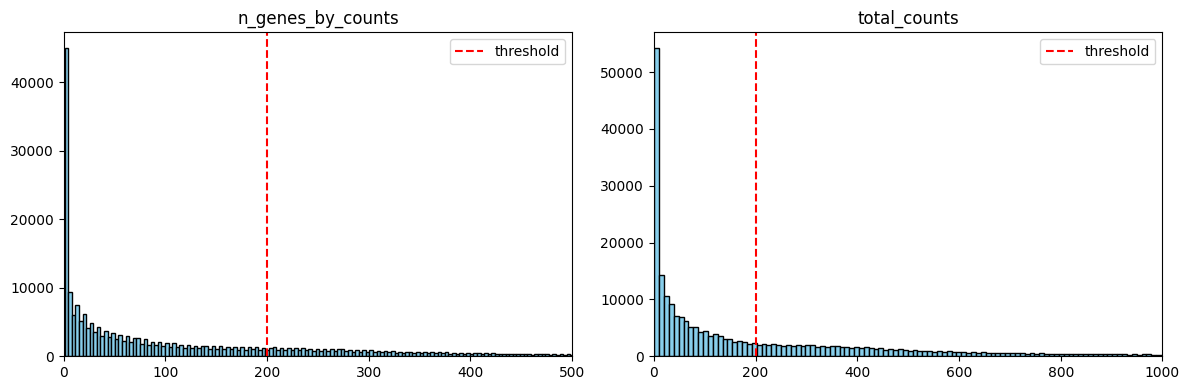

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# n_genes_by_counts
axs[0].hist(
    adataTrans2.obs['n_genes_by_counts'],
    bins=1000,
    color='skyblue',
    edgecolor='black'
)
axs[0].set_title('n_genes_by_counts')
axs[0].set_xlim(0, 500)    # 横坐标

# total_counts
axs[1].hist(
    adataTrans2.obs['total_counts'],
    bins=1000,              
    color='skyblue',
    edgecolor='black'
)
axs[1].set_title('total_counts')
axs[1].set_xlim(0, 1000)     # 横坐标
axs[0].axvline(200, color='red', linestyle='--', label='threshold')
axs[0].legend()

axs[1].axvline(200, color='red', linestyle='--', label='threshold')
axs[1].legend()

plt.tight_layout()
plt.show()



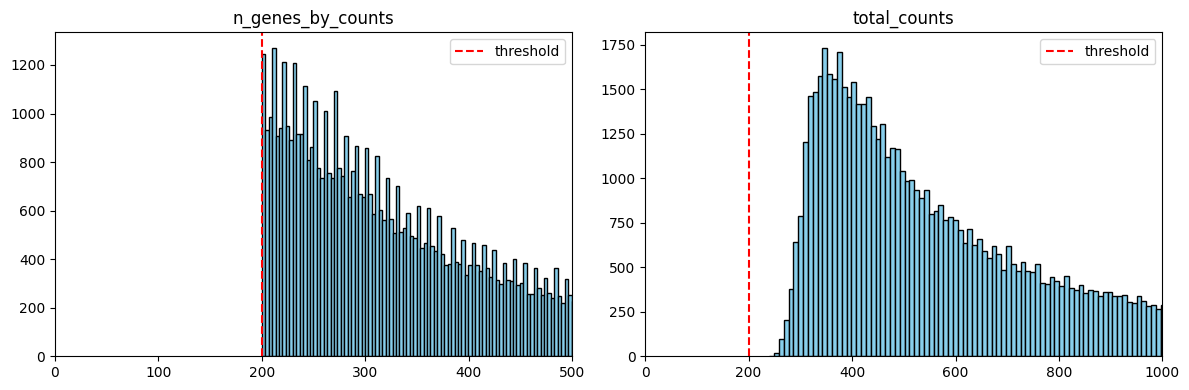

In [20]:
sc.pp.filter_cells(adataTrans2, min_genes=200)  # this does nothing, in this specific case
sc.pp.filter_genes(adataTrans2, min_cells=100)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# n_genes_by_counts
axs[0].hist(
    adataTrans2.obs['n_genes_by_counts'],
    bins=1000,
    color='skyblue',
    edgecolor='black'
)
axs[0].set_title('n_genes_by_counts')
axs[0].set_xlim(0, 500)      # 横坐标

# total_counts
axs[1].hist(
    adataTrans2.obs['total_counts'],
    bins=1000,
    color='skyblue',
    edgecolor='black'
)
axs[1].set_title('total_counts')
axs[1].set_xlim(0, 1000)     # 横坐标
axs[0].axvline(200, color='red', linestyle='--', label='threshold')
axs[0].legend()

axs[1].axvline(200, color='red', linestyle='--', label='threshold')
axs[1].legend()

plt.tight_layout()
plt.show()



preprocess前:
0.0 1154.0
CPM后:
0.0 2900.7634
log变换后:
0.0 7.973074


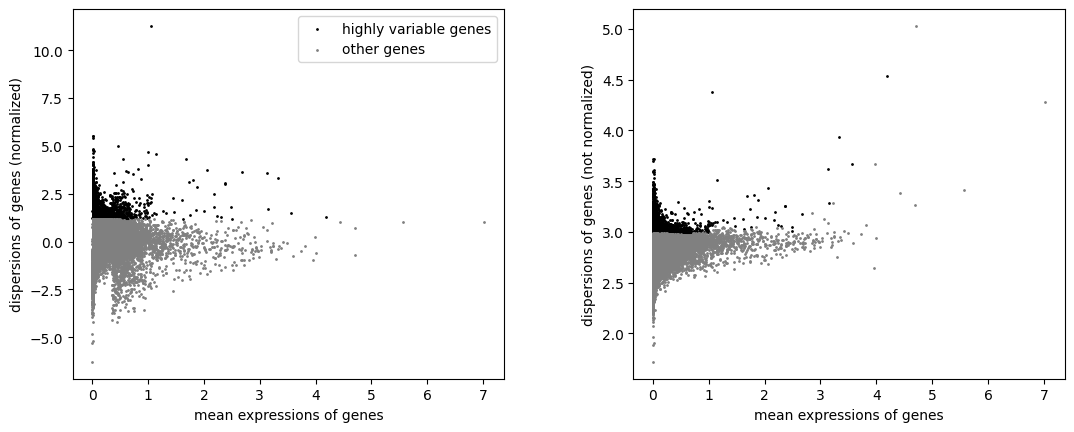

In [22]:
print("preprocess前:")
print(adataTrans2.X.min(), adataTrans2.X.max())
adataTrans2.layers['raw'] = adataTrans2.X.copy()

# CPM
sc.pp.normalize_total(adataTrans2, target_sum=1e4)
print('CPM后:')
print(adataTrans2.X.min(), adataTrans2.X.max())

# log 
sc.pp.log1p(adataTrans2)
print("log变换后:")
print(adataTrans2.X.min(), adataTrans2.X.max())

# # scale
# sc.pp.scale(adataTrans2, zero_center=False)

# find highly_variable_genes
sc.pp.highly_variable_genes(
    adataTrans2,
    n_top_genes=2000,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    flavor="seurat",
)
sc.pl.highly_variable_genes(adataTrans2)



In [24]:
adataTrans2

AnnData object with n_obs × n_vars = 113690 × 22916
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    obsm: 'spatial'
    layers: 'raw'

In [26]:
def plot_spatial_counts_from_X(adata, layer="raw", s=2, title=""):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.sparse import issparse

    if "spatial" in adata.obsm:
        xy = adata.obsm["spatial"]
    else:
        xy = adata.obs[["x","y"]].values

    X = adata.layers[layer] if layer is not None else adata.X
    if issparse(X):
        counts = np.asarray(X.sum(axis=1)).ravel()
    else:
        counts = X.sum(axis=1)

    plt.figure(figsize=(6,6))
    plt.scatter(
        xy[:,0], xy[:,1],
        c=np.log1p(counts),
        s=s, cmap="viridis"
    )
    plt.colorbar(label="log1p(total counts)")
    plt.gca().set_aspect("equal")
    plt.title(title)
    plt.tight_layout()
    plt.show()

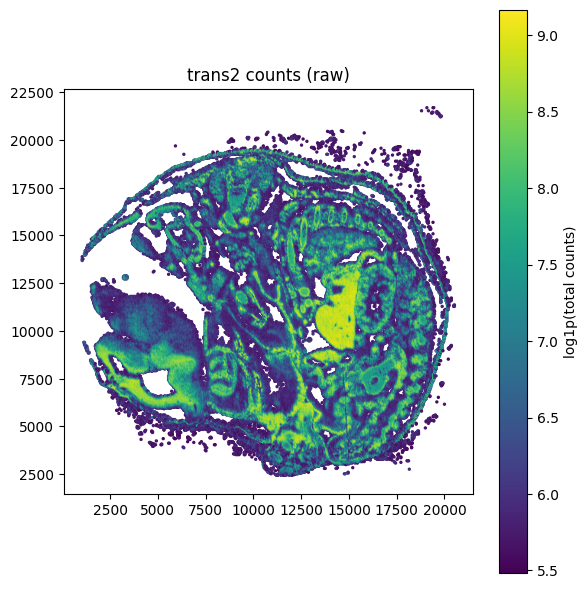

In [28]:
plot_spatial_counts_from_X(
    adataTrans2,
    layer="raw",
    title="trans2 counts (raw)"
)

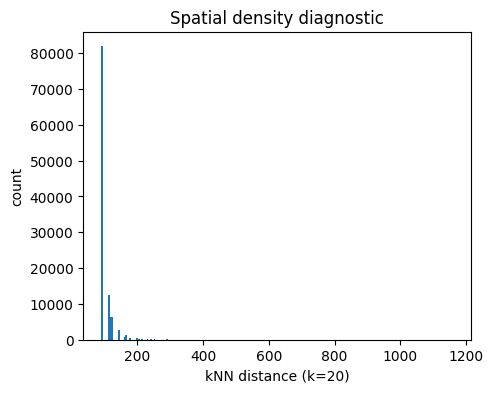

In [35]:
xy = adataTrans2.obsm["spatial"]

# kNN（推荐 k=15~30）
k = 20
nbrs = NearestNeighbors(n_neighbors=k).fit(xy)
dists, _ = nbrs.kneighbors(xy)

# 用第 k 个邻居距离作为“局部稀疏度”
knn_dist = dists[:, -1]   # 越大 = 越稀疏
adataTrans2.obs["knn_dist"] = knn_dist
plt.figure(figsize=(5,4))
plt.hist(knn_dist, bins=200)
plt.xlabel("kNN distance (k=20)")
plt.ylabel("count")
plt.title("Spatial density diagnostic")
plt.show()

保留点数: 110163 / 113690


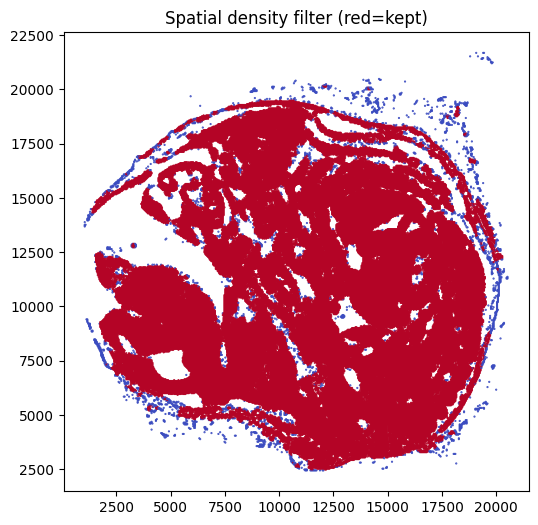

In [36]:
thr = np.percentile(knn_dist, 97)
keep = knn_dist < thr
print("保留点数:", keep.sum(), "/", len(keep))

adataTrans2 = adataTrans2[keep].copy()
plt.figure(figsize=(6,6))
plt.scatter(
    xy[:,0], xy[:,1],
    c=keep,
    s=0.3,
    cmap="coolwarm"
)
plt.title("Spatial density filter (red=kept)")
plt.gca().set_aspect("equal")
plt.show()



In [37]:
adataTrans2.write_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataTrans2.h5ad')

In [ ]:
#create meta adata

In [8]:



###############################preprocess################################################
#1.构建Anndata
# 读入intensity文件
intensity1 = pd.read_csv("/p1/data/jtian/SA/embyro/input/e1/e1_no_normalized.csv", sep=";", header = 0, index_col = 0)
intensity2 = pd.read_csv("/p1/data/jtian/SA/embyro/input/e2/e2_no_normalized.csv", sep=";", header = 0, index_col = 0)

intensity1.index.name ='mz'
intensity2.index.name ='mz'

print("--- 数据形状 (Shape) ---")
print(intensity1.shape)
print(intensity2.shape)


print("\n--- 数据预览 (Head) ---")
print("样本 1:")
print(intensity1.head())
print("\n样本 2:")
print(intensity2.head())

# 读入coords文件
SpotIndex1 = pd.read_csv("/p1/data/jtian/SA/embyro/input/e1/e1_spot_index.csv", sep=";", header = 0, index_col = 0)
SpotIndex2 = pd.read_csv("/p1/data/jtian/SA/embyro/input/e2/e2_spot_index.csv", sep=";", header = 0, index_col = 0)

SpotIndex1.index.name ='SpotIndex'
print('xiugaiqian')
print(SpotIndex1.index[:5].tolist())
SpotIndex1.index=SpotIndex1.index+1
print('xiugaihou')
print(SpotIndex1.index[:5].tolist())

SpotIndex2.index.name ='SpotIndex'
print('xiugaiqian')
print(SpotIndex2.index[:5].tolist())
SpotIndex2.index=SpotIndex2.index+1
print('xiugaihou')
print(SpotIndex2.index[:5].tolist())

print("--- 数据形状 (Shape) ---")
print(SpotIndex1.shape)
print(SpotIndex2.shape)

print("\n--- 数据预览 (Head) ---")
print("样本 1:")
print(SpotIndex1.head())
print("\n样本 2:")
print(SpotIndex2.head())

SAMPLE_IDS = [1, 2]

# --- 1. 初始化容器 ---
all_X_t = []  # 存储转置后的特征矩阵 (Spot x Metabolite)
all_obs = []  # 存储所有的观测值 (坐标和样本ID)
all_var_names = None # 存储代谢物 mz 值/索引

print("开始整合数据...")

for sample_id in SAMPLE_IDS:
    # 动态获取已加载的 Pandas DataFrame 变量
    intensity_df = globals()[f"intensity{sample_id}"]
    coords_df    = globals()[f"SpotIndex{sample_id}"]


    print(f"\n整合样本 {sample_id}...")

    # --- 2. 处理特征矩阵 (创建 .X) ---
    # AnnData 要求：行是 Spot，列是 Metabolite。
    # 原始 intensity_df 形状是 (Metabolite, Spot)。需要转置 (T) 并提取值 (.values)。
    X_t = intensity_df.T.values
    

    # --- 3. 处理观测值 (创建 .obs) ---
    # 确保 Spot 顺序一致性：使用 intensity_df 的列名 (Spot Index) 来对 coords_df 进行索引排序。
    spot_indices_intensity = intensity_df.columns

    # 提取坐标信息并确保顺序匹配
    # CAST 要求 .obs 包含 'x', 'y', 'sample'
    try:
        # 提取数字部分并转换为整数（处理 "Spot 1" -> 1）
        spot_indices_numeric = []
        for spot_str in spot_indices_intensity:
            numeric_id = int(spot_str.replace("Spot ", "").strip())
            spot_indices_numeric.append(numeric_id)
            # 第二步：使用转换后的数字索引匹配 coords_df 的索引
        obs_t = coords_df.loc[spot_indices_numeric, ['x', 'y']].copy()
    except KeyError as e:
        print(f"❌ 错误：样本 {sample_id} 的坐标文件缺少 'x'/'y' 列，或 Spot 索引不存在。缺失项: {e}")
        continue
    except ValueError as e:
        print(f"❌ 错误：样本 {sample_id} 的 Spot 索引格式解析失败（不是 'Spot 数字' 格式）。详情: {e}")
        continue
    except Exception as e:
        print(f"❌ 错误：样本 {sample_id} 的 Spot 索引不匹配或存在其他问题。详细信息: {e}")
        continue
    
    # 添加样本 ID
    obs_t[['x', 'y']] = np.floor(obs_t[['x', 'y']].to_numpy()).astype(int)       #########################
    obs_t['sample'] = 'meta'

    var_names = intensity_df.index.astype(str)
    var_df = pd.DataFrame(index=var_names)

    adata = ad.AnnData(
        X=X_t,
        obs=obs_t,
        var=var_df,
        dtype=X_t.dtype
    )

    out_file = os.path.join(output_path, f"adataMeta{sample_id}.h5ad")
    adata.write_h5ad(out_file)

--- 数据形状 (Shape) ---
(194, 131877)
(194, 154723)

--- 数据预览 (Head) ---
样本 1:
            Spot 1     Spot 2  Spot 3  Spot 4     Spot 5     Spot 6  Spot 7  \
mz                                                                            
401.859003     0.0   0.000000     0.0     0.0   0.000000   0.000000     0.0   
402.009728     0.0   0.000000     0.0     0.0   4.000000   2.800000     0.0   
402.989814    17.0  21.200001    19.0    47.0  42.400002  75.199997    18.6   
403.996528     0.0  10.000000     9.0     0.0  14.200000   7.400000     0.0   
404.008648    11.0   0.000000     4.6     9.2   4.200000   8.600000     0.0   

            Spot 8     Spot 9    Spot 10  ...  Spot 131868  Spot 131869  \
mz                                        ...                             
401.859003     0.0   0.000000   0.000000  ...          0.0     0.000000   
402.009728     0.0   0.000000   0.000000  ...          0.0     8.800000   
402.989814    27.0  32.799999  67.400002  ...          8.0    74.00000

In [ ]:

adataMeta1=sc.read_h5ad("/p1/data/jtian/SA/embyro/output/adataMeta1.h5ad")
adataMeta2=sc.read_h5ad("/p1/data/jtian/SA/embyro/output/adataMeta2.h5ad")
print(adataMeta1.obs.head())
print(adataMeta2.obs.head())

     x    y sample
40   0   40  trans
160  0  160  trans
200  0  200  trans
360  0  360  trans
440  0  440  trans
     x    y sample
40   0   40  trans
120  0  120  trans
320  0  320  trans
400  0  400  trans
560  0  560  trans
               x     y sample
SpotIndex                    
1          12914  9154   meta
2          12934  9154   meta
3          12954  9154   meta
4          12974  9154   meta
5          12994  9154   meta
              x     y sample
SpotIndex                   
131878     4269  9426   meta
131879     4289  9426   meta
131880     4309  9426   meta
131881     4329  9426   meta
131882     4349  9426   meta


In [ ]:

print("adataMeta1.X:", type(adataMeta1.X), adataMeta1.X.shape)
print("adataMeta2.X:", type(adataMeta2.X), adataMeta2.X.shape)


adataTrans1.X: <class 'scipy.sparse._csr.csr_matrix'> (256626, 44374)
adataTrans2.X: <class 'scipy.sparse._csr.csr_matrix'> (291179, 45582)
adataMeta1.X: <class 'numpy.ndarray'> (131877, 194)
adataMeta2.X: <class 'numpy.ndarray'> (154723, 194)


In [ ]:


print("adataMeta1.X[:5,:5]:\n",  adataMeta1.X[:5, :5])
print("adataMeta2.X[:5,:5]:\n",  adataMeta2.X[:5, :5])


adataTrans1.X[:5,:5]:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
adataTrans2.X[:5,:5]:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
adataMeta1.X[:5,:5]:
 [[ 0.          0.         17.          0.         11.        ]
 [ 0.          0.         21.20000076 10.          0.        ]
 [ 0.          0.         19.          9.          4.5999999 ]
 [ 0.          0.         47.          0.          9.19999981]
 [ 0.          4.         42.40000153 14.19999981  4.19999981]]
adataMeta2.X[:5,:5]:
 [[ 8.39999962  0.         37.          0.         29.        ]
 [ 9.19999981  0.         21.          0.         10.        ]
 [ 7.19999981  0.         43.59999847  0.          9.80000019]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.         24.          0.          0.        ]]


In [ ]:

print("\nadataMeta1.var.head():\n", adataMeta1.var.head())
print("\nadataMeta2.var.head():\n", adataMeta2.var.head())



adataTrans1.var.head():
 Empty DataFrame
Columns: []
Index: [ENSMUSG00000000001, ENSMUSG00000000003, ENSMUSG00000000028, ENSMUSG00000000031, ENSMUSG00000000037]

adataTrans2.var.head():
 Empty DataFrame
Columns: []
Index: [ENSMUSG00000000001, ENSMUSG00000000003, ENSMUSG00000000028, ENSMUSG00000000031, ENSMUSG00000000037]

adataMeta1.var.head():
 Empty DataFrame
Columns: []
Index: [401.8590030451, 402.00972830628, 402.98981395725, 403.99652806728, 404.00864813494]

adataMeta2.var.head():
 Empty DataFrame
Columns: []
Index: [401.8590030451, 402.00972830628, 402.98981395725, 403.99652806728, 404.00864813494]


In [7]:
#处理adataMeta1
print("preprocess前")
print(adataMeta1.X[:5,:5])
print(np.min(adataMeta1.X), np.max(adataMeta1.X))
adataMeta1.layers['raw']=adataMeta1.X.copy()
# # cheng10quzheng
# adataMeta1.X = (adataMeta1.X * 10).round().astype(int)
# print("×10取整")
# print(adataMeta1.X[:5,:5])
# print(np.min(adataMeta1.X), np.max(adataMeta1.X))

# CPM
sc.pp.normalize_total(adataMeta1, target_sum=1e4)
print('CPM后')
print(adataMeta1.X[:5,:5])
print(np.min(adataMeta1.X), np.max(adataMeta1.X))

# log + scale
sc.pp.log1p(adataMeta1)
sc.pp.scale(adataMeta1, zero_center=False)

print('log变换+scale')
print(adataMeta1.X[:5,:5])
print(np.min(adataMeta1.X), np.max(adataMeta1.X))

preprocess前
[[ 0.          0.         17.          0.         11.        ]
 [ 0.          0.         21.20000076 10.          0.        ]
 [ 0.          0.         19.          9.          4.5999999 ]
 [ 0.          0.         47.          0.          9.19999981]
 [ 0.          4.         42.40000153 14.19999981  4.19999981]]
0.0 1106.3333740234
CPM后
[[  0.           0.         162.97053868   0.         105.45152503]
 [  0.           0.         169.80830409  80.09825376   0.        ]
 [  0.           0.         135.21206947  64.04782238  32.73555298]
 [  0.           0.         207.89714311   0.          40.69475908]
 [  0.          19.28206434 204.38988932  68.45132747  20.24616663]]
0.0 4285.714353293208
log变换+scale
[[0.         0.         4.96706397 0.         1.92418332]
 [0.         0.         5.00685661 1.92229887 0.        ]
 [0.         0.         4.78641365 1.82585347 1.45046907]
 [0.         0.         5.20292168 0.         1.53778992]
 [0.         1.62775106 5.1864301  1.854

In [13]:
# 处理 adataMeta2
print("preprocess前")
print(adataMeta2.X[:5, :5])
print(np.min(adataMeta2.X), np.max(adataMeta2.X))

adataMeta2.layers['raw'] = adataMeta2.X.copy()

# # cheng10quzheng
# adataMeta2.X = (adataMeta2.X * 10).round().astype(int)
# print("×10取整")
# print(adataMeta2.X[:5, :5])
# print(np.min(adataMeta2.X), np.max(adataMeta2.X))

# CPM
sc.pp.normalize_total(adataMeta2, target_sum=1e4)
print('CPM后')
print(adataMeta2.X[:5, :5])
print(np.min(adataMeta2.X), np.max(adataMeta2.X))

# log + scale
sc.pp.log1p(adataMeta2)
sc.pp.scale(adataMeta2, zero_center=False)

print('log变换+scale')
print(adataMeta2.X[:5, :5])
print(np.min(adataMeta2.X), np.max(adataMeta2.X))


preprocess前
[[ 8.39999962  0.         37.          0.         29.        ]
 [ 9.19999981  0.         21.          0.         10.        ]
 [ 7.19999981  0.         43.59999847  0.          9.80000019]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.         24.          0.          0.        ]]
0.0 581.66668701172
CPM后
[[107.58196212   0.         473.87294991   0.         371.41393371]
 [190.08264153   0.         433.88429944   0.         206.61157116]
 [144.36572323   0.         874.2146499    0.         196.49779898]
 [  0.           0.           0.           0.           0.        ]
 [  0.           0.         560.57302663   0.           0.        ]]
0.0 5785.1239009906985
log变换+scale
[[2.63067144 0.         9.04134894 0.         2.57104779]
 [2.94786732 0.         8.91229868 0.         2.31727127]
 [2.79440284 0.         9.93832056 0.         2.29558179]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         9.28736112 0.  

In [38]:
adataTrans1=sc.read_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataTrans1.h5ad')
adataTrans2=sc.read_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataTrans2.h5ad')
adataTrans1.layers['beforeScaled']=adataTrans1.X.copy()
adataTrans2.layers['beforeScaled']=adataTrans2.X.copy()


In [39]:
adataTrans1

AnnData object with n_obs × n_vars = 81042 × 20406
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'knn_dist'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'spatial'
    layers: 'raw', 'beforeScaled'

In [40]:
adataTrans2

AnnData object with n_obs × n_vars = 110163 × 22916
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'knn_dist'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'spatial'
    layers: 'raw', 'beforeScaled'

In [ ]:
print(adataTrans1.X.min(), adataTrans1.X.max())
sc.pp.scale(adataTrans1, zero_center=False)
print(adataTrans1.X.min(), adataTrans1.X.max())

print(adataTrans2.X.min(), adataTrans2.X.max())
sc.pp.scale(adataTrans2, zero_center=False)
print(adataTrans2.X.min(), adataTrans2.X.max())


0.0 8.031057
0.0 73.18603235709841
0.0 7.973074
0.0 93.09881811590553


In [48]:
adataTrans1 = sc.read_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataTrans1.h5ad')
adataTrans2 = sc.read_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataTrans2.h5ad')
adataMeta1  = sc.read_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataMeta1.h5ad')
adataMeta2  = sc.read_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataMeta2.h5ad')
adataTrans1.obs["sample"] = "trans1"
adataTrans2.obs["sample"] = "trans2"
adataMeta1.obs["sample"]  = "meta1"
adataMeta2.obs["sample"]  = "meta2"
print(adataTrans1.obs["sample"].unique())
print(adataTrans2.obs["sample"].unique())
print(adataMeta1.obs["sample"].unique())
print(adataMeta2.obs["sample"].unique())



['trans1']
['trans2']
['meta1']
['meta2']


In [49]:
adataTrans1.write_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataTrans1.h5ad')
adataTrans2.write_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataTrans2.h5ad')
adataMeta1.write_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataMeta1.h5ad')
adataMeta2.write_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataMeta2.h5ad')


In [50]:
adataTrans1

AnnData object with n_obs × n_vars = 81042 × 20406
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'knn_dist'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'spatial'
    layers: 'beforeScaled', 'raw'

In [26]:
adataTrans1 = sc.read_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataTrans1.h5ad')
adataTrans2 = sc.read_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataTrans2.h5ad')
adataMeta1  = sc.read_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataMeta1.h5ad')
adataMeta2  = sc.read_h5ad('/p1/data/jtian/SA/embyro/output/demo1_adataMeta2.h5ad')


In [27]:
def get_xy(adata):
    # 优先 obs[x,y]，否则 obsm["spatial"]
    if ("x" in adata.obs.columns) and ("y" in adata.obs.columns):
        return np.asarray(adata.obs[["x", "y"]], dtype=np.float32)
    if "spatial" in adata.obsm:
        return np.asarray(adata.obsm["spatial"], dtype=np.float32)
    raise ValueError("找不到坐标：需要 adata.obs['x','y'] 或 adata.obsm['spatial']")

def norm_xy_to(XY, target=2000):
    XY = XY.astype(np.float32)
    XY = XY - XY.min(axis=0)
    mx = XY.max(axis=0)
    s = target / (mx.max() + 1e-8)
    return XY * s

In [28]:
# ========= 1) 先做 coords_raw（按你给的处理方式） =========
coords_raw = {
    "trans1": norm_xy_to(get_xy(adataTrans1), target=2000),
    "trans2": norm_xy_to(get_xy(adataTrans2), target=2000),
    "meta1":  norm_xy_to(get_xy(adataMeta1),  target=2000),
    "meta2":  norm_xy_to(get_xy(adataMeta2),  target=2000),
}

# ========= 3) trans1 =========
cx, cy = 250.0, 750.0
r = 400.0
r2 = r * r

xy = coords_raw["trans1"].astype(np.float32, copy=False)
mask = ((xy[:, 0] - cx) ** 2 + (xy[:, 1] - cy) ** 2) <= r2
adataTrans1.obs["in_circle_700_1000_r100"] = mask

xy_keep = np.full((adataTrans1.n_obs, 2), np.nan, dtype=np.float32)
xy_keep[mask] = xy[mask]
adataTrans1.obsm["xy_circle_700_1000_r100"] = xy_keep
adataTrans1.uns["xy_circle_700_1000_r100_sel"] = xy[mask]  # 真实筛出来的短坐标（可选）

# ========= 4) trans2 =========
cx, cy = 375.0, 625.0
r = 400.0
r2 = r * r
xy = coords_raw["trans2"].astype(np.float32, copy=False)
mask = ((xy[:, 0] - cx) ** 2 + (xy[:, 1] - cy) ** 2) <= r2
adataTrans2.obs["in_circle_700_1000_r100"] = mask

xy_keep = np.full((adataTrans2.n_obs, 2), np.nan, dtype=np.float32)
xy_keep[mask] = xy[mask]
adataTrans2.obsm["xy_circle_700_1000_r100"] = xy_keep
adataTrans2.uns["xy_circle_700_1000_r100_sel"] = xy[mask]

# ========= 5) meta1 =========
cx, cy = 1000.0, 250.0
r = 400.0
r2 = r * r
xy = coords_raw["meta1"].astype(np.float32, copy=False)
mask = ((xy[:, 0] - cx) ** 2 + (xy[:, 1] - cy) ** 2) <= r2
adataMeta1.obs["in_circle_700_1000_r100"] = mask

xy_keep = np.full((adataMeta1.n_obs, 2), np.nan, dtype=np.float32)
xy_keep[mask] = xy[mask]
adataMeta1.obsm["xy_circle_700_1000_r100"] = xy_keep
adataMeta1.uns["xy_circle_700_1000_r100_sel"] = xy[mask]

# ========= 6) meta2 =========
cx, cy = 625.0, 1625.0
r = 400.0
r2 = r * r
xy = coords_raw["meta2"].astype(np.float32, copy=False)
mask = ((xy[:, 0] - cx) ** 2 + (xy[:, 1] - cy) ** 2) <= r2
adataMeta2.obs["in_circle_700_1000_r100"] = mask

xy_keep = np.full((adataMeta2.n_obs, 2), np.nan, dtype=np.float32)
xy_keep[mask] = xy[mask]
adataMeta2.obsm["xy_circle_700_1000_r100"] = xy_keep
adataMeta2.uns["xy_circle_700_1000_r100_sel"] = xy[mask]

# ========= 7) 快速检查 =========
print("trans1 in-circle:", int(adataTrans1.obs["in_circle_700_1000_r100"].sum()))
print("trans2 in-circle:", int(adataTrans2.obs["in_circle_700_1000_r100"].sum()))
print("meta1  in-circle:", int(adataMeta1.obs["in_circle_700_1000_r100"].sum()))
print("meta2  in-circle:", int(adataMeta2.obs["in_circle_700_1000_r100"].sum()))


trans1 in-circle: 15617
trans2 in-circle: 17829
meta1  in-circle: 22220
meta2  in-circle: 22820


In [29]:
m1 = adataTrans1.obs["in_circle_700_1000_r100"].values
m2 = adataTrans2.obs["in_circle_700_1000_r100"].values
m3 = adataMeta1.obs["in_circle_700_1000_r100"].values
m4 = adataMeta2.obs["in_circle_700_1000_r100"].values

adataTrans1_roi = adataTrans1[m1].copy()
adataTrans2_roi = adataTrans2[m2].copy()
adataMeta1_roi  = adataMeta1[m3].copy()
adataMeta2_roi  = adataMeta2[m4].copy()


In [34]:
adataMeta1_roi.write_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataMeta1_roi.h5ad")
adataMeta2_roi.write_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataMeta2_roi.h5ad")
adataTrans1_roi.write_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataTrans1_roi.h5ad")
adataTrans2_roi.write_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataTrans2_roi.h5ad")

In [2]:
adataMeta1_roi  = sc.read_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataMeta1_roi.h5ad")
adataMeta2_roi  = sc.read_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataMeta2_roi.h5ad")
adataTrans1_roi = sc.read_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataTrans1_roi.h5ad")
adataTrans2_roi = sc.read_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataTrans2_roi.h5ad")

In [11]:
adataMeta1


AnnData object with n_obs × n_vars = 131877 × 194
    obs: 'x', 'y', 'sample', 'in_circle_700_1000_r100'
    var: 'mean', 'std'
    uns: 'log1p', 'xy_circle_700_1000_r100_sel'
    obsm: 'xy_circle_700_1000_r100'
    layers: 'raw'

In [21]:
coords_raw['meta1']

array([[ 919.03723, 2000.     ],
       [ 923.4136 , 2000.     ],
       [ 927.7899 , 2000.     ],
       ...,
       [1203.5011 ,    0.     ],
       [1207.8774 ,    0.     ],
       [1212.2538 ,    0.     ]], dtype=float32)

[[   0.       730.43475]
 [   0.       734.7826 ]
 [   0.       739.13043]
 ...
 [1999.9999   900.     ]
 [1999.9999   904.3478 ]
 [1999.9999   908.6956 ]]


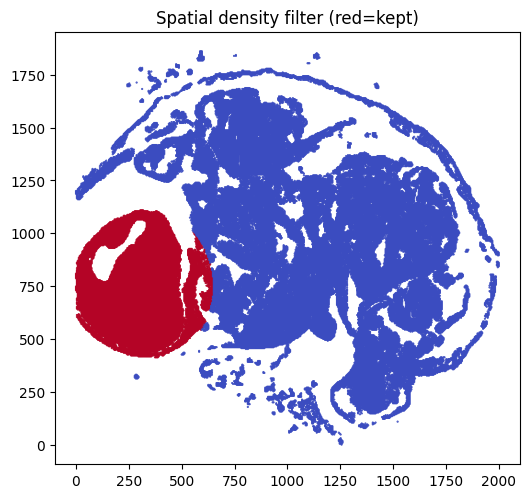

In [30]:
keep=adataTrans1.obs['in_circle_700_1000_r100']
xy=coords_raw['trans1']
print(xy)
plt.figure(figsize=(6,6))
plt.scatter(
    xy[:,0], xy[:,1],
    c=keep,
    s=0.3,
    cmap="coolwarm"
)
plt.title("Spatial density filter (red=kept)")
plt.gca().set_aspect("equal")
plt.show()

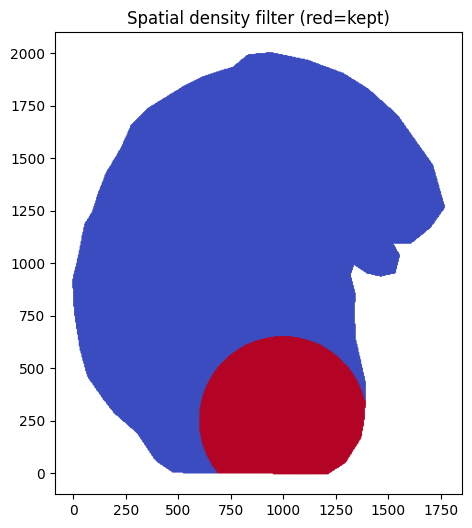

In [31]:
keep=adataMeta1.obs['in_circle_700_1000_r100']
xy=coords_raw['meta1']
plt.figure(figsize=(6,6))
plt.scatter(
    xy[:,0], xy[:,1],
    c=keep,
    s=0.3,
    cmap="coolwarm"
)
plt.title("Spatial density filter (red=kept)")
plt.gca().set_aspect("equal")
plt.show()

[[   0.     1254.2373]
 [   0.     1258.4746]
 [   0.     1266.9492]
 ...
 [2000.     1033.8983]
 [2000.     1038.1356]
 [2000.     1042.3729]]


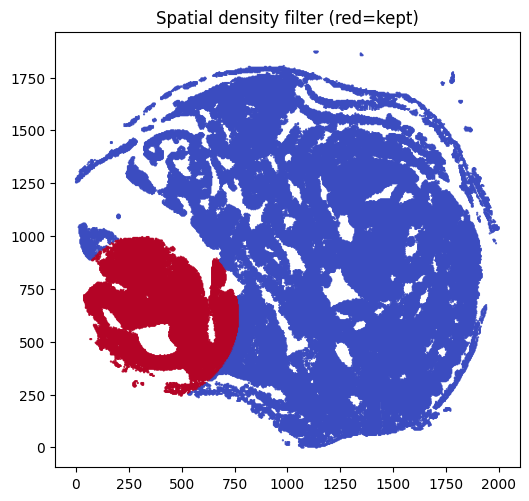

In [32]:
keep=adataTrans2.obs['in_circle_700_1000_r100']
xy=coords_raw['trans2']
print(xy)
plt.figure(figsize=(6,6))
plt.scatter(
    xy[:,0], xy[:,1],
    c=keep,
    s=0.3,
    cmap="coolwarm"
)
plt.title("Spatial density filter (red=kept)")
plt.gca().set_aspect("equal")
plt.show()

[[ 904.45856 1999.9999 ]
 [ 908.70483 1999.9999 ]
 [ 912.9511  1999.9999 ]
 ...
 [ 963.90656    0.     ]
 [ 968.15283    0.     ]
 [ 972.3991     0.     ]]


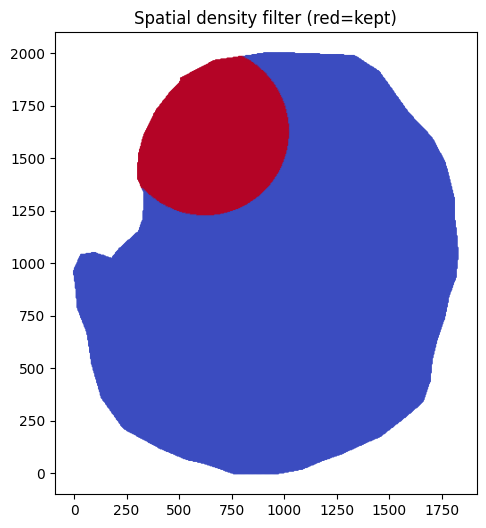

In [33]:
keep=adataMeta2.obs['in_circle_700_1000_r100']
xy=coords_raw['meta2']
print(xy)
plt.figure(figsize=(6,6))
plt.scatter(
    xy[:,0], xy[:,1],
    c=keep,
    s=0.3,
    cmap="coolwarm"
)
plt.title("Spatial density filter (red=kept)")
plt.gca().set_aspect("equal")
plt.show()

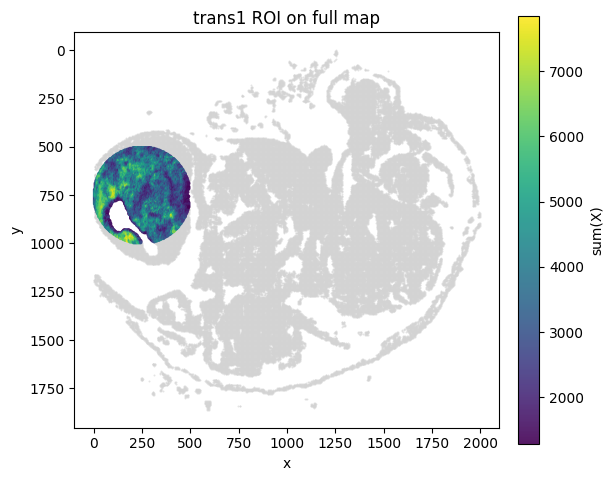

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import issparse

def get_gene_or_vec(adata, gene=None, layer=None):
    """
    返回长度 n_obs 的向量，用于给点上色：
    - gene=None: 用每个细胞的总表达（sum）
    - gene="GeneA": 用指定基因表达
    """
    if layer is None:
        X = adata.X
    else:
        X = adata.layers[layer]

    if gene is None:
        v = X.sum(axis=1)
    else:
        gi = adata.var_names.get_loc(gene)
        v = X[:, gi]

    v = np.asarray(v).reshape(-1)
    return v

def plot_roi_overlay(adata, coords_raw_xy, mask_key, gene=None, layer=None, s_bg=2, s_roi=6, title=None):
    xy = coords_raw_xy
    mask = adata.obs[mask_key].to_numpy().astype(bool)

    v = get_gene_or_vec(adata, gene=gene, layer=layer)

    plt.figure(figsize=(6,6))
    # 背景：全图灰点
    plt.scatter(xy[:,0], xy[:,1], s=s_bg, c="lightgray", linewidths=0, alpha=0.6)
    # ROI：彩色点
    sc = plt.scatter(xy[mask,0], xy[mask,1], s=s_roi, c=v[mask], linewidths=0, alpha=0.9)
    plt.colorbar(sc, fraction=0.046, pad=0.04, label=("sum(X)" if gene is None else gene))
    plt.gca().set_aspect("equal")
    plt.gca().invert_yaxis()  # 如果你想和 scanpy spatial 一致可开；不需要就注释掉
    plt.title(title or f"ROI overlay ({mask_key})")
    plt.xlabel("x"); plt.ylabel("y")
    plt.show()

# 用法示例：trans1 看某个基因
plot_roi_overlay(
    adataTrans1,
    coords_raw["trans1"],
    mask_key="in_circle_700_1000_r100",
    gene=None,          # None 就是 sum(X)；也可以 gene="Sox2" 之类
    layer=None,
    title="trans1 ROI on full map"
)


In [21]:
embed_dict = torch.load("/p2/zulab/jtian/data/SA/embyro/output_em6/demo_embed_dict.pt",map_location='cpu')

In [22]:
print(embed_dict.keys())

odict_keys(['trans1', 'meta1'])
